# Lab Report 4: Portfolio Construction

**Ethan Wang, Kevin Yang**  
**RSM338**  
**March 9, 2026**

## 1. From Prices to Returns

### 1.1 Data Preparation
This analysis requires three datasets: DGS10.csv, market.csv, and prices.csv. We will load them in and perform some data cleaning to make sure that the date values are aligned.  
First, we load in the csv data. Then, we will then filter the data for only the last 10 years. We will handle missing data by dropping stocks that have over 10% of data missing. For the remaining missing values, we will forward fill using ffill(). We can now align the three datasets by date. Finally, we convert the risk-free data from an annualized percentage to daily log return.  
At the end, we should have data for stock prices, market index, and risk free rate all aligned to the same date index.

In [1]:
import pandas as pd
import numpy as np

# Stock prices
prices = pd.read_csv("prices.csv", parse_dates=["Date"], index_col="Date")

# Market index
market = pd.read_csv("market.csv", parse_dates=["Date"], index_col="Date")

# Risk-free rate
rf = pd.read_csv("DGS10.csv", parse_dates=["observation_date"], index_col="observation_date")
rf.index.name = "Date"

print("Prices:", prices.shape)
print("Market:", market.shape)
print("Risk-free:", rf.shape)

Prices: (13912, 503)
Market: (13912, 1)
Risk-free: (16727, 1)


In [2]:
# Filter for only the last 10 years
# Determine date range
end_date = prices.index.max()
start_date = end_date - pd.DateOffset(years=10)

# Filter datasets
prices = prices.loc[start_date:end_date]
market = market.loc[start_date:end_date]
rf = rf.loc[start_date:end_date]

print("Filtered prices shape:", prices.shape)

Filtered prices shape: (2516, 503)


In [3]:
# Minimum number of required observations
threshold = int(0.9 * len(prices))

# Drop stocks with too many missing values
prices = prices.dropna(axis=1, thresh=threshold)

print("Remaining number of stocks:", prices.shape[1])

Remaining number of stocks: 476


In [4]:
# Forward fill remaining missing values
prices = prices.ffill()

In [5]:
# Find common trading dates
common_dates = prices.index.intersection(market.index).intersection(rf.index)

# Align datasets
prices = prices.loc[common_dates]
market = market.loc[common_dates]
rf = rf.loc[common_dates]

print("Final number of observations:", len(common_dates))

Final number of observations: 2516


In [6]:
# Convert risk-free rate from annual percentage to daily log returns
rf_daily = np.log(1 + rf["DGS10"]/100) / 252
rf_daily = rf_daily.to_frame(name="rf")

rf_daily.head() 

,rf
Date,
2015-03-04,0.000083
2015-03-05,0.000083
2015-03-06,0.000088
2015-03-09,0.000086
2015-03-10,0.000084


In [7]:
prices.head()

,A,AAPL,ABBV,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,...,WTW,WY,WYNN,XEL,XOM,XYL,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2015-03-04,38.679150,28.706537,39.771614,38.854362,18.811941,77.067551,77.629997,47.521145,35.235287,69.662910,...,107.532234,23.238997,121.084457,25.248211,56.308872,31.467518,47.678905,106.658325,91.029999,42.945576
2015-03-05,38.881775,28.230852,37.521389,39.209774,18.989443,78.033951,78.620003,47.561821,35.534653,69.799713,...,108.143448,23.144056,121.241493,25.503759,56.024681,31.370514,47.940876,107.035538,91.160004,43.159248
2015-03-06,38.246311,28.273281,36.716324,38.432858,18.976765,76.864090,77.550003,47.138695,34.614117,69.196228,...,106.875664,22.398127,119.496986,24.569178,55.307724,31.009026,47.131145,104.493889,89.629997,42.527561
2015-03-09,38.439720,28.393879,36.650341,38.705601,19.179623,76.965813,77.930000,47.569962,34.718884,69.872101,...,107.622734,22.743965,115.868446,24.883141,55.004173,31.079567,47.297848,105.032761,89.400002,43.001328
2015-03-10,37.417477,27.806528,36.848297,38.160099,18.954576,74.651497,76.010002,46.544689,34.067768,68.512344,...,106.649300,22.540529,112.963898,24.941561,54.422886,30.594639,46.369045,103.739487,87.800003,42.453228


In [8]:
market.tail()

,^GSPC
Date,
2025-02-26,5956.060059
2025-02-27,5861.569824
2025-02-28,5954.500000
2025-03-03,5849.720215
2025-03-04,5778.149902


In [9]:
print("Final dataset summary")
print("Stock trading days:", prices.shape[0])
print("Market Index trading days:", market.shape[0])
print("Risk-free Rate trading days:", rf_daily.shape[0])
print("Stocks:", prices.shape[1])

Final dataset summary
Stock trading days: 2516
Market Index trading days: 2516
Risk-free Rate trading days: 2516
Stocks: 476


Taking a quick look at our cleaned datasets, we end up with 2516 trading days of data across 476 stocks.  

### 1.2 Daily Log Returns

### Problem 1a — Computing Log Returns
We compute daily log returns for each stock and for the market index using the formula:

$
r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)
$

where $P_t$ represents the price at time $t$ and $P_{t-1}$ is the price on the previous trading day.

In [10]:
# Compute log returns
stock_returns = np.log(prices / prices.shift(1))
market_returns = np.log(market / market.shift(1))

# Remove only the first row created by shift
stock_returns = stock_returns.iloc[1:]
market_returns = market_returns.iloc[1:]

print(stock_returns.shape)
print(market_returns.shape)

(2515, 476)
(2515, 1)


In [11]:
rf_daily = rf_daily.loc[stock_returns.index]

print(rf_daily.shape)

(2515, 1)


Log returns are preferred because you can get returns over a time period by simply summing up individual returns. This additivity is useful for when we need to do tasks such as converting daily returns to monthly returns. Second, log returns are also more statistically convenient, because sums or scalar multiples of random variables are easier to analyze than exponentiated products. Finally, log returns have no lower bound, while simple returns cannot go past -100%.

### 1.3 Components of Mean Variance Optimization

Now we will estimate inputs for mean-variance optimization. We will find the excess return vector $\hat{\mu}$, and the covariance matrix $\hat{\sigma}$.  

The expected excess return for stock (i) is calculated as:  
$
\hat{\mu}_i = 252 \cdot \bar{r}_i - r_f
$  
where $ \bar{r}_i $ is the average daily log return for stock $i$, $r_f$ is the daily risk-free rate, and 252 represents the approximate number of trading days in a year.

The sample covariance matrix of daily returns is annualized using
$
\hat{\Sigma} = 252 \cdot \hat{\Sigma}_{daily}
$

In [12]:
# Average daily log return for each stock
mean_daily_returns = stock_returns.mean()

# Average daily risk-free rate
rf_mean_daily = rf_daily.mean().values[0]

# Annualized expected excess returns
mu_hat = 252 * mean_daily_returns - rf_mean_daily

# Annualized covariance matrix
Sigma_hat = 252 * stock_returns.cov()

# Dimensions of the objects
print("mu_hat shape:", mu_hat.shape)
print("Sigma_hat shape:", Sigma_hat.shape)

mu_hat shape: (476,)
Sigma_hat shape: (476, 476)


We get that the dimensions of $\hat{\mu}$ are 476x1, and the dimensions of $\hat{\sigma}$ are 476x476. This is in line with our expected result, as there is one excess return for each of the 476 stocks, and the covariance matrix has covariances for each stock pair.

### 1.4 Outlier Stocks

To find and analyze stocks that are outliers in our dataset, we decided to go with a graphical approach. We decided to plot a scatter plot showing average returns and volatility in order to identify stocks that stand out.

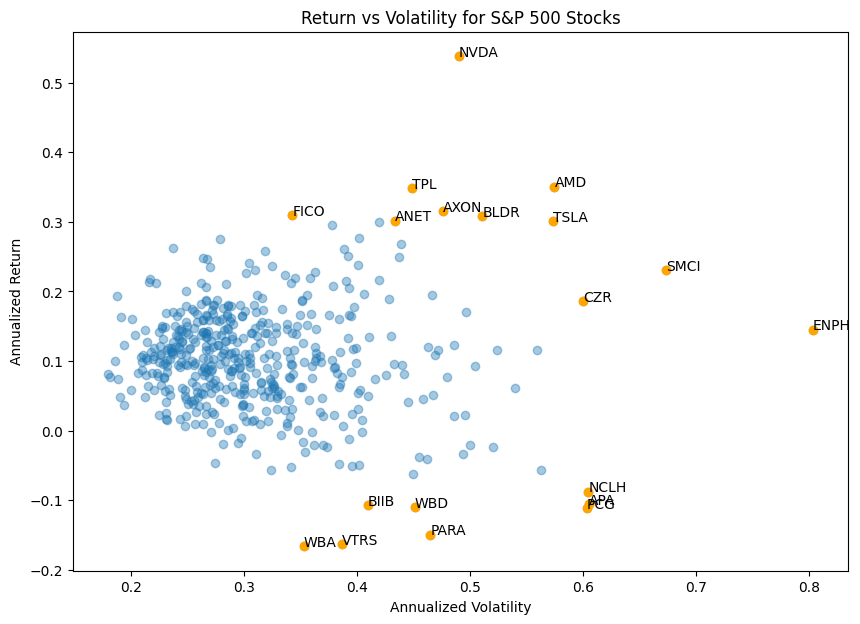

In [13]:
import matplotlib.pyplot as plt

# Annualized statistics
avg_returns = stock_returns.mean() * 252
volatility = stock_returns.std() * np.sqrt(252)

# Create dataframe
stats = pd.DataFrame({
    "Return": avg_returns,
    "Volatility": volatility
})

# Identify outliers
top_returns = stats.nlargest(8, "Return")
low_returns = stats.nsmallest(8, "Return")
high_vol = stats.nlargest(8, "Volatility")

outliers = pd.concat([top_returns, low_returns, high_vol]).drop_duplicates()

# Plot
plt.figure(figsize=(10,7))

plt.scatter(stats["Volatility"], stats["Return"], alpha=0.4)

# Highlight outliers
plt.scatter(outliers["Volatility"], outliers["Return"], color="orange",  label="Outliers")

# Label outliers
for ticker, row in outliers.iterrows():
    plt.text(row["Volatility"], row["Return"], ticker)

plt.xlabel("Annualized Volatility")
plt.ylabel("Annualized Return")
plt.title("Return vs Volatility for S&P 500 Stocks")

plt.show()

The plot highlights stocks who are in the top 8 of highest return, lowest return, and highest volatility. From the plot we can choose stocks that stand out to analyze. We decided to pick VTRS (low annualized return), TPL (high annualized return), and ENPH (high volatility).
  
VTRS Viatris is a major pharmacutical company. In the years 2016-2020, they suffered a significant drop in stock prices due to a decline in drug prices and regulatory issues, where the Epipen was investigated. Furthermore, in 2020 Mylan merged with Upjohn to form Viatris, which also caused much uncertainty. This statistical anomaly was mostly obvious in hindsight due to the volatility in the pharma industry caused by regulations and unpredictable research, and overall lower drug prices. Furthermore, we see many pharma companies such as WBA Walgreens, and BIIB Biogen all highlighted as outliers with low annualized returns.  
  
TPL Texas Pacific Land Corp owns land that is used to drill for oil and gas. Their huge returns can be attributed to the increase in oil prices and energy prices during this time period. We think that this statistical anomaly is only obvious in hindsight because of the unpredictability of energy prices. It would be impossible to predict global events that could shift the price of oil/gas.  
  
ENPH Enphase Energy is a renewable energy company. They experienced high swings in their price due to government policy shifts. For instance, their stock price has swung widly during election periods, and was high under Biden but has now decreased under Trump. This is predictable because clean energy has overall been volatile, with firms very dependent on government subsidies and benefits. Furthermore, they are very sensitive to foreign policy as well such as tariffs, as there is strong competition overseas for clean energy.

## 2. The Security Market Line
### 2.1 Data Preparation

In [14]:
# Calculate monthly log returns for stocks, market, and risk-free rate
monthly_prices = prices.resample("ME").last()
monthly_returns = np.log(monthly_prices / monthly_prices.shift(1)).dropna()

# Market_returns and rf_daily are already daily log returns
# just sum them up for the month
monthly_market_returns = market_returns.resample("ME").sum().dropna()
monthly_rf = rf_daily.resample("ME").sum().dropna()

# Ensure all dataframes share the exact same dates before the regression
common_dates = monthly_returns.index.intersection(monthly_market_returns.index).intersection(monthly_rf.index)
monthly_returns = monthly_returns.loc[common_dates]
monthly_market_returns = monthly_market_returns.loc[common_dates]
monthly_rf = monthly_rf.loc[common_dates]

monthly_returns.head()
#monthly_market_returns.head()
#monthly_rf.head()

,A,AAPL,ABBV,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,...,WTW,WY,WYNN,XEL,XOM,XYL,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2015-11-30,0.102124,-0.005821,-0.023791,0.002675,-0.032848,0.000187,0.031093,0.024806,-0.216742,-0.008427,...,0.036918,0.092423,-0.101523,0.000842,-0.004459,0.028566,0.022313,-0.034637,0.042018,0.084189
2015-12-31,0.002492,-0.116791,0.018571,-0.000223,-0.038255,-0.025696,0.026755,-0.101497,0.005193,-0.011855,...,0.055234,-0.070504,0.097379,0.016064,-0.046496,-0.022217,0.007420,0.017675,-0.141041,0.025789
2016-01-31,-0.104803,-0.078223,-0.065635,-0.164738,-0.032049,0.009903,-0.052560,-0.026746,-0.036933,-0.019427,...,-0.116878,-0.157548,-0.027102,0.062343,-0.001284,-0.015183,-0.002719,-0.032998,-0.142494,-0.104978
2016-02-29,-0.008000,-0.001288,-0.005296,0.023242,0.005757,-0.051323,-0.045682,-0.008090,-0.002011,0.019073,...,-0.010097,0.014344,0.209195,0.033954,0.038151,0.044002,0.001381,-0.024993,0.022591,-0.047328
2016-03-31,0.064790,0.119746,0.044937,0.076741,0.045462,0.140638,0.096750,0.110649,0.037889,0.063804,...,0.050098,0.187452,0.124657,0.064443,0.042024,0.089192,0.121715,0.098918,0.110527,0.076627


### 2.2 CAPM Regression Using Monthly Returns

In [15]:
import statsmodels.api as sm

# 1. Extract the specific columns as 1D Series so pandas math works perfectly
market_series = monthly_market_returns['^GSPC']
rf_series = monthly_rf['rf']

# Calculate Market Excess Return (Series - Series)
market_excess = market_series - rf_series

# 2. Add a constant to X to estimate Alpha (the intercept)
X = sm.add_constant(market_excess)

# Storage for our results
capm_results = []

# 3. The Loop
for ticker in monthly_returns.columns:
    # Calculate the Stock's Excess Return (Series - Series)
    y = monthly_returns[ticker] - rf_series
    
    # Fit the OLS regression (missing='drop' handles any legitimate NaN values safely)
    model = sm.OLS(y, X, missing='drop').fit()
    
    # Extract the metrics required by the assignment
    alpha = model.params.iloc[0] # Intercept
    beta = model.params.iloc[1]  # Slope
    beta_se = model.bse.iloc[1]  # Standard Error of Beta
    r_squared = model.rsquared   # R-squared
    
    # Save to our list
    capm_results.append({
        'Ticker': ticker,
        'Alpha': alpha,
        'Beta': beta,
        'Beta_SE': beta_se,
        'R_Squared': r_squared
    })

# Convert the results into a DataFrame
df_capm = pd.DataFrame(capm_results).set_index('Ticker')
df_capm.head()

,Alpha,Beta,Beta_SE,R_Squared
Ticker,,,,
A,0.001130,1.134441,0.111611,0.482062
AAPL,0.008717,1.207058,0.127339,0.447356
ABBV,0.008111,0.622545,0.144101,0.143942
ABT,0.003918,0.787346,0.098842,0.363725
ACGL,0.005048,0.697300,0.140307,0.182014


In [16]:
# Calculate the target Beta values for the 25th, 50th, and 75th percentiles
q25_target = df_capm['Beta'].quantile(0.25)
q50_target = df_capm['Beta'].quantile(0.50)
q75_target = df_capm['Beta'].quantile(0.75)

# Find the specific tickers whose Beta is closest to those targets
q25_ticker = (df_capm['Beta'] - q25_target).abs().idxmin()
q50_ticker = (df_capm['Beta'] - q50_target).abs().idxmin()
q75_ticker = (df_capm['Beta'] - q75_target).abs().idxmin()

# Extract their actual Beta values for the printout
q25_val = df_capm.loc[q25_ticker, 'Beta']
q50_val = df_capm.loc[q50_ticker, 'Beta']
q75_val = df_capm.loc[q75_ticker, 'Beta']

print(f"25th Percentile (Low Beta):  {q25_ticker} (Beta = {q25_val:.2f})")
print(f"50th Percentile (Mid Beta):  {q50_ticker} (Beta = {q50_val:.2f})")
print(f"75th Percentile (High Beta): {q75_ticker} (Beta = {q75_val:.2f})")

25th Percentile (Low Beta):  O (Beta = 0.79)
50th Percentile (Mid Beta):  FFIV (Beta = 1.05)
75th Percentile (High Beta): LYV (Beta = 1.31)


### 2.3 Excess Stock Returns vs Excess Market Returns

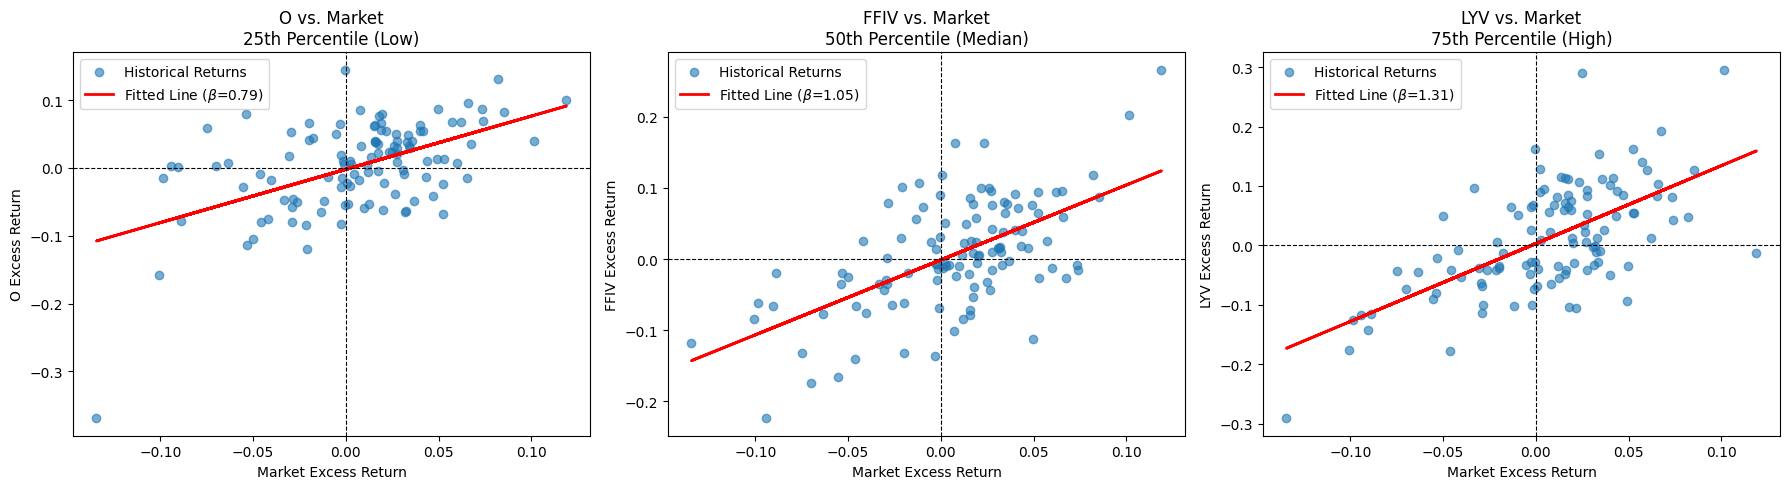

In [17]:
import matplotlib.pyplot as plt

# Put the three quartile tickers into a list
chosen_tickers = [q25_ticker, q50_ticker, q75_ticker]

# Set up a side-by-side figure
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, ticker in enumerate(chosen_tickers):
    # X is the Market Excess Return, Y is the Stock Excess Return
    x_vals = market_series - rf_series
    y_vals = monthly_returns[ticker] - rf_series
    
    # Extract the Alpha and Beta 
    alpha = df_capm.loc[ticker, 'Alpha']
    beta = df_capm.loc[ticker, 'Beta']
    
    # Scatter plot of the actual historical monthly returns
    axes[i].scatter(x_vals, y_vals, alpha=0.6, label='Historical Returns')
    
    # Plot the fitted Security Market regression line: y = alpha + beta * x
    axes[i].plot(x_vals, alpha + (beta * x_vals), color='red', linewidth=2, label=f'Fitted Line ($\\beta$={beta:.2f})')
    
    # Formatting
    axes[i].axhline(0, color='black', linewidth=0.8, linestyle='--')
    axes[i].axvline(0, color='black', linewidth=0.8, linestyle='--')
    
    # Label the titles based on their quartile position
    titles = ["25th Percentile (Low)", "50th Percentile (Median)", "75th Percentile (High)"]
    axes[i].set_title(f"{ticker} vs. Market\n{titles[i]}")
    axes[i].set_xlabel("Market Excess Return")
    axes[i].set_ylabel(f"{ticker} Excess Return")
    axes[i].legend()

plt.tight_layout()
plt.show()

**Low Beta Stock - Realty Income (NYSE: O)**

The low-beta stock, Realty Income, has a relatively flat slope of 0.79. As a real estate investment trust (REIT), the company generates highly predictable cash flows through long-term commercial leases and is structured to pay out consistent dividends. Since its core business remains relatively stable regardless of the broader economic environment, the stock is heavily insulated from sudden market swings. Mathematically, when the broader market moves by 1%, Realty Income typically only moves by 0.79%. This visually demonstrates that it carries lower systematic risk, making it a classic conservative asset for investors during volatile periods.


**Median Beta Stock- F5 Inc. (NASDAQ: FFIV)**

The median-beta stock, F5 Inc., has a slope of 1.05, placing it almost perfectly in line with the market average. Because the S&P 500 is heavily weighted toward the technology sector, it is common for mature enterprise technology companies to closely mirror the index. F5's revenue is tied to broader corporate IT spending, which tends to rise and fall nearly in tandem with general economic health. A beta of 1.05 implies that its systematic risk is practically identical to the rest of the market - when the market moves 1%, FFIV moves roughly 1.05%.

**High Beta Stock - Live Nation (NYSE: LYV)**

The high-beta stock, Live Nation, displays a notably steeper slope of 1.31, meaning it actively amplifies the market's movements. This makes perfect sense, as live entertainment is seen as a "cheap luxury." When the economy is booming, consumers have excess disposable income to spend on concerts and festivals, causing the stock to surge faster than the market. Conversely, during an economic downturn, expensive event tickets are often the first expense households cut. This 1.31 beta clearly signals to investors that the company is highly sensitive to the economic cycle and carries significantly higher systematic risk than the average stock.

### 2.4 Security Market Line

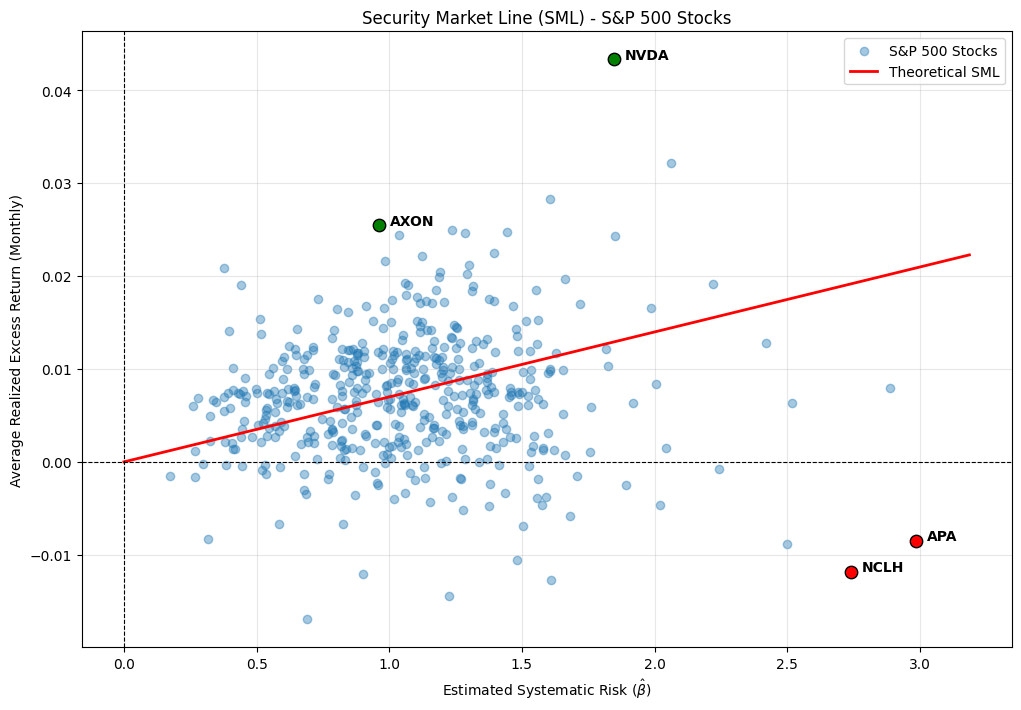

Extreme Positive Alpha Outliers (Above SML):
AXON: Monthly Alpha = 0.0188
NVDA: Monthly Alpha = 0.0304

Extreme Negative Alpha Outliers (Below SML):
NCLH: Monthly Alpha = -0.0310
APA: Monthly Alpha = -0.0293


In [18]:
# Calculate Average Excess Returns for all stocks and the market
avg_stock_excess = (monthly_returns.sub(rf_series, axis=0)).mean()
avg_mkt_excess = market_excess.mean()

# Scatter plot of all stocks with the SML
plt.figure(figsize=(12, 8))

# All 476 stocks: X = Beta, Y = Average Realized Excess Return
plt.scatter(df_capm['Beta'], avg_stock_excess, alpha=0.4, label='S&P 500 Stocks')

# Theoretical SML
# The theoretical SML passes through (0,0) and (1, avg_mkt_excess)
# Draw it from Beta = 0 to slightly past the max beta in our dataset
x_sml = np.linspace(0, df_capm['Beta'].max() + 0.2, 100)
y_sml = x_sml * avg_mkt_excess
plt.plot(x_sml, y_sml, color='red', linewidth=2, label='Theoretical SML')

# Highlight the Extreme Outliers (Top 2 and Bottom 2 Alphas)
# Sort by Alpha to find the extremes for Task 2(d)
df_sorted_alpha = df_capm.sort_values('Alpha')
bottom_alphas = df_sorted_alpha.head(2).index
top_alphas = df_sorted_alpha.tail(2).index
outliers = list(bottom_alphas) + list(top_alphas)

for ticker in outliers:
    x_val = df_capm.loc[ticker, 'Beta']
    y_val = avg_stock_excess[ticker]
    
    # Color red if negative alpha, green if positive alpha
    color = 'red' if df_capm.loc[ticker, 'Alpha'] < 0 else 'green'
    
    plt.scatter(x_val, y_val, color=color, s=80, edgecolor='black', zorder=5)
    plt.text(x_val + 0.04, y_val, ticker, fontsize=10, weight='bold')

# Formatting
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title("Security Market Line (SML) - S&P 500 Stocks")
plt.xlabel("Estimated Systematic Risk ($\hat{\\beta}$)")
plt.ylabel("Average Realized Excess Return (Monthly)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

# Print out the exact Alpha values
print("Extreme Positive Alpha Outliers (Above SML):")
for t in top_alphas:
    print(f"{t}: Monthly Alpha = {df_capm.loc[t, 'Alpha']:.4f}")

print("\nExtreme Negative Alpha Outliers (Below SML):")
for t in bottom_alphas:
    print(f"{t}: Monthly Alpha = {df_capm.loc[t, 'Alpha']:.4f}")

### 2.5 Explaining Abnormal Stock Performance
dadadadad add stuff here

### 2.6 Connecting to CAPM Framework
adadadada add more stuff here

## 3. The Efficient Frontier
### 3.1 The Closed-Form Solution

To find the closed-form solution, we use Markowitz Mean-Variance Optimization:

$$\min_{\vec{w}} \frac{1}{2}\vec{w}^\top \Sigma \vec{w}$$

The formula is trying to minimize variance by optimizing the weights of each stock in the portfolio. However, it needs constraints, otherwise it would just tell us to hold only cash (zero risk):

Our target return: $\vec{w}^\top \mu = \mu_{\text{target}}$,
and our portfolio weights: $\vec{w}^\top \vec{1} = 1$

The first constraint is telling our optimization function to that it needs to match our exact target return. The second constraint is telling the function that all the weights must equal to 1, meaning 100% of our capital must be used (no cash left).

Our scalars $A, B, C , D$ will help our formula determine the appropriate weights.

$$ A = \vec{1}^\top \Sigma^{-1} \mu, \quad B = \mu^\top \Sigma^{-1} \mu, \quad C = \vec{1}^\top \Sigma^{-1} \vec{1}, \quad D = BC - A^2 $$

These scalars are going to help us determine our two multipliers, ${\lambda}_1$ and ${\lambda}_2$, which are going to be needed to determine our optimal weights:
$$\vec{w}^* = \boldsymbol{\Sigma}^{-1}(\lambda_1 \boldsymbol{\mu} + \lambda_2 \vec{1})$$

$A$ multiplies the ones vector ($\vec{1}$) by the returns vector ($\mu$). It acts as the "bridge" or trade-off variable between the two constraints: the requirement to be fully invested (100% weights) and our desire to hit a specific target return.

$B$ multiplies the expected returns ($\mu^\top$ and $\mu$) while dividing by risk ($\Sigma^{-1}$). This scalar captures the risk-adjusted return potential of the portfolio. It is essentially the building block for the maximum possible Sharpe ratio.

$C$ represents the absolute floor of risk in the portfolio. $1/C$ is exactly the variance of the Global Minimum Variance (GMV) portfolio. It tells you the lowest possible volatility you can achieve while staying 100% invested.

$D$ defines the exact shape and "bend" of the efficient frontier curve. A larger $D$ means the frontier opens up wider, offering better risk-return trade-offs.

Finally, the two multipliers are calculated using our scalars and our target return:
$$\lambda_1 = \frac{C \cdot \mu_{\text{target}} - A}{D}, \quad \lambda_2 = \frac{B - A \cdot \mu_{\text{target}}}{D}$$
$\lambda_1$ and $\lambda_2$ are known as Lagrange multipliers. They are the penalty terms of the model. $\lambda_1$ adjusts the weights to ensure the portfolio hits the exact $\mu_{\text{target}}$, while $\lambda_2$ ensures the portfolio remains 100% invested.

### 3.2 Plotting the Efficient Frontier

Calculated Scalars -> A: 14.70, B: 23.27, C: 151.15, D: 3301.67


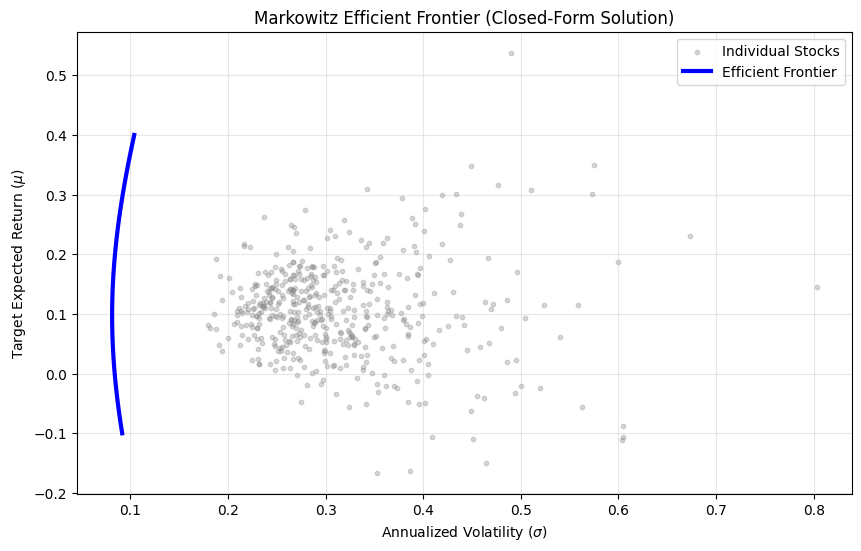

In [19]:
# 1. Extract raw numpy arrays from your pandas variables
mu_vec = mu_hat.values
Sigma_mat = Sigma_hat.values
ones_vec = np.ones(len(mu_vec))

# 2. Invert the covariance matrix
Sigma_inv = np.linalg.inv(Sigma_mat)

# 3. Calculate the scalars A, B, C, D
A = ones_vec.T @ Sigma_inv @ mu_vec
B = mu_vec.T @ Sigma_inv @ mu_vec
C = ones_vec.T @ Sigma_inv @ ones_vec
D = B * C - A**2

print(f"Calculated Scalars -> A: {A:.2f}, B: {B:.2f}, C: {C:.2f}, D: {D:.2f}")

# 4. Define a range of target returns to sweep over (e.g., -10% to +40% annualized)
target_returns = np.linspace(-0.10, 0.40, 100)

# Storage for the plot
port_risks = []
port_returns = []

# 5. The Efficient Frontier Loop
for mu_target in target_returns:
    # Calculate Lagrange multipliers for this specific target
    lambda_1 = (C * mu_target - A) / D
    lambda_2 = (B - A * mu_target) / D
    
    # Calculate the optimal weights using the closed-form formula
    w_star = Sigma_inv @ (lambda_1 * mu_vec + lambda_2 * ones_vec)
    
    # Calculate resulting portfolio risk (Variance = w^T * Sigma * w)
    port_variance = w_star.T @ Sigma_mat @ w_star
    port_volatility = np.sqrt(port_variance)
    
    # Save the coordinates
    port_risks.append(port_volatility)
    port_returns.append(mu_target)

# 6. Plotting the Frontier
plt.figure(figsize=(10, 6))

# Plot all the individual stocks faintly in the background for context
plt.scatter(np.sqrt(np.diag(Sigma_mat)), mu_vec, color='gray', alpha=0.3, s=10, label='Individual Stocks')

# Plot the efficient frontier curve
plt.plot(port_risks, port_returns, color='blue', linewidth=3, label='Efficient Frontier')

# Formatting
plt.title('Markowitz Efficient Frontier (Closed-Form Solution)')
plt.xlabel('Annualized Volatility ($\sigma$)')
plt.ylabel('Target Expected Return ($\mu$)')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [22]:
# Calculate GMV Portfolio Weights
# Formula: w_gmv = (Sigma_inv * 1) / C
w_gmv = (Sigma_inv @ ones_vec) / C

# Calculate GMV Return and Volatility
mu_gmv = w_gmv.T @ mu_vec
sig_gmv = np.sqrt(w_gmv.T @ Sigma_mat @ w_gmv)

# Calculate Tangency Portfolio Weights
w_tan = (Sigma_inv @ mu_vec) / A

# Calculate Tangency Return and Volatility
mu_tan = w_tan.T @ mu_vec
sig_tan = np.sqrt(w_tan.T @ Sigma_mat @ w_tan)

# Results
print("--- GLOBAL MINIMUM VARIANCE (GMV) PORTFOLIO ---")
print(f"Expected Excess Return: {mu_gmv:.4f} ({mu_gmv*100:.2f}%)")
print(f"Standard Deviation:     {sig_gmv:.4f} ({sig_gmv*100:.2f}%)")
print(f"Max Long Position:      {w_gmv.max()*100:.2f}%")
print(f"Max Short Position:     {w_gmv.min()*100:.2f}%\\n")

print("\n--- TANGENCY PORTFOLIO (MAX SHARPE) ---")
print(f"Expected Excess Return: {mu_tan:.4f} ({mu_tan*100:.2f}%)")
print(f"Standard Deviation:     {sig_tan:.4f} ({sig_tan*100:.2f}%)")
print(f"Max Long Position:      {w_tan.max()*100:.2f}%")
print(f"Max Short Position:     {w_tan.min()*100:.2f}%")

# Create a DataFrame to see the most extreme Tangency weights
df_weights = pd.DataFrame({
    'GMV Weight': w_gmv,
    'Tangency Weight': w_tan
}, index=prices.columns)

print("\nTop 3 Long Positions (Tangency):")
print(df_weights['Tangency Weight'].nlargest(3))
print("\nTop 3 Short Positions (Tangency):")
print(df_weights['Tangency Weight'].nsmallest(3))

--- GLOBAL MINIMUM VARIANCE (GMV) PORTFOLIO ---
Expected Excess Return: 0.0973 (9.73%)
Standard Deviation:     0.0813 (8.13%)
Max Long Position:      9.54%
Max Short Position:     -9.09%\n

--- TANGENCY PORTFOLIO (MAX SHARPE) ---
Expected Excess Return: 1.5828 (158.28%)
Standard Deviation:     0.3281 (32.81%)
Max Long Position:      31.03%
Max Short Position:     -37.23%

Top 3 Long Positions (Tangency):
GOOG    0.310336
ATO     0.301919
REG     0.285417
Name: Tangency Weight, dtype: float64

Top 3 Short Positions (Tangency):
D     -0.372298
LEN   -0.313613
FRT   -0.294009
Name: Tangency Weight, dtype: float64


### 3.3 Global Minimum Variance and Tangency Portfolios
#### **Portfolio Metrics:**

**Global Minimum Variance (GMV) Portfolio:**

Expected Excess Return: 9.73%

Standard Deviation: 8.13%

Most Extreme Weights: 9.54% (Long), -9.09% (Short)

**Tangency Portfolio (Maximum Sharpe):**

Expected Excess Return: 158.28%

Standard Deviation: 32.81%

Most Extreme Weights: 31.03% (Long), -37.23% (Short)


The weights produced by the closed-form solution are highly unreasonable and would be impossible to implement in a real-world pension fund. While the GMV portfolio remains somewhat grounded, the Tangency portfolio requires extreme, highly concentrated long and short positions. For instance, it suggests shorting over 37% of the portfolio's capital in Dominion Energy (D) and nearly 31% in Lennar (LEN) just to go heavily long on stocks like Google (GOOG) at 31% and Atmos Energy (ATO) at 30%.

These extreme allocations paired with the absurdly high expected return of 158.28% arrive due to unconstrained optimization trying to fit all the random noise in our sample. The solver treats the historical 10-year sample means and covariances as the absolute truth. Consequently, it aggressively exploits every random correlation in the backwards-looking dataset to force the highest possible Sharpe ratio, resulting in a theoretical portfolio that is completely detached from reality.

### 3.4 Using a Solver to Find the Efficient Frontier

In [31]:
# Install cvxpy in venv if not already installed
#%pip install cvxpy

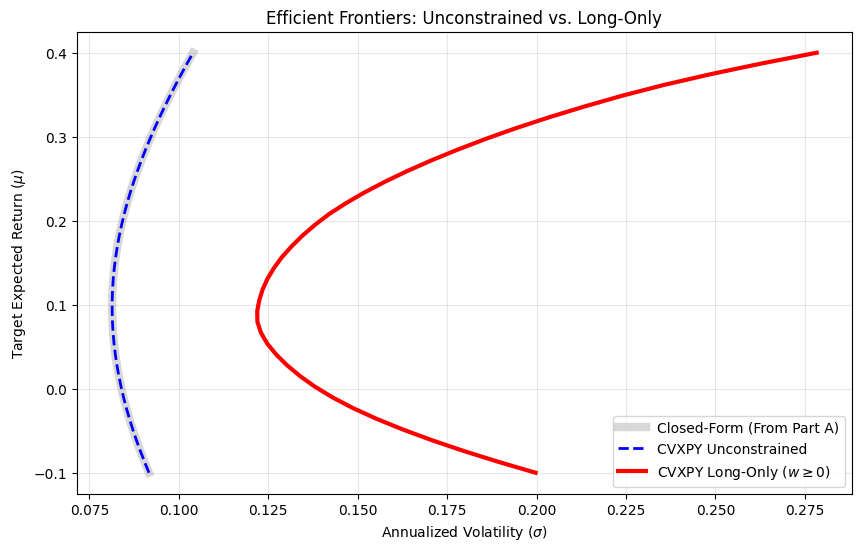

In [32]:
import cvxpy as cp

# Sweep across a range of target returns again
cvx_target_returns = np.linspace(-0.10, 0.40, 40)

# Storage for calculated risks
cvx_unconstrained_risks = []
cvx_constrained_risks = []
valid_constrained_returns = [] 

# Setup the Core CVXPY Problem
n_assets = len(mu_vec)
w = cp.Variable(n_assets)

# The objective is to minimize variance
# In CVXPY, w^T * Sigma * w is written as cp.quad_form(w, Sigma_mat)
variance = cp.quad_form(w, Sigma_mat)
objective = cp.Minimize(0.5 * variance)

# The Solver Loop
for mu_target in cvx_target_returns:
    
    # Unconstrained
    constraints_unconstrained = [
        w @ mu_vec == mu_target, # Target return constraint
        cp.sum(w) == 1           # 100% invested constraint
    ]
    prob_unconstrained = cp.Problem(objective, constraints_unconstrained)
    prob_unconstrained.solve()
    
    if prob_unconstrained.status == 'optimal':
        cvx_unconstrained_risks.append(np.sqrt(variance.value))
    else:
        cvx_unconstrained_risks.append(np.nan)
        
    # Long-Only Constrained
    constraints_constrained = [
        w @ mu_vec == mu_target, 
        cp.sum(w) == 1,
        w >= 0  # Long-Only constraint
    ]
    prob_constrained = cp.Problem(objective, constraints_constrained)
    prob_constrained.solve()
    
    if prob_constrained.status == 'optimal':
        cvx_constrained_risks.append(np.sqrt(variance.value))
        valid_constrained_returns.append(mu_target)

# Plotting the Comparison
plt.figure(figsize=(10, 6))

# Plot the original Closed-Form as a thick faint line to verify CVXPY matches
plt.plot(port_risks, port_returns, color='gray', linewidth=6, alpha=0.3, label='Closed-Form (From Part A)')

# Plot CVXPY Unconstrained
plt.plot(cvx_unconstrained_risks, cvx_target_returns, color='blue', linestyle='--', linewidth=2, label='CVXPY Unconstrained')

# Plot CVXPY Long-Only
plt.plot(cvx_constrained_risks, valid_constrained_returns, color='red', linewidth=3, label=r'CVXPY Long-Only ($w \geq 0$)')

plt.title('Efficient Frontiers: Unconstrained vs. Long-Only')
plt.xlabel(r'Annualized Volatility ($\sigma$)')
plt.ylabel(r'Target Expected Return ($\mu$)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

By plotting the unconstrained results from the cvxpy quadratic programming solver against the results from our closed-form algebraic solution, we can visually verify that the frontiers perfectly overlap. This confirms that both methods successfully minimize the same quadratic objective and yield the exact same optimal risk-return trade-offs when short selling is permitted.

### 3.5 Long-Only Constraint
When we look at the graph, the unconstrained curve is clearly better than the long-only curve. For any target return you pick, the long-only portfolio sits further to the right, meaning you have to take on more risk (volatility) to get the exact same reward. Essentially, banning short sales ($w_i \ge 0$) hurts the portfolio in two major ways. First, you lose the ability to hedge effectively. When the model is allowed to short, it deliberately shorts specific stocks to "cancel out" risk. When you can only buy and hold, you are stuck absorbing all of the risk of those assets. Second, it puts a hard cap on your maximum returns. To hit high returns, the unconstrained model essentially liquidates bad stocks by shorting them and uses that cash to overload on the best performing stocks. The long-only portfolio cannot do this, meaning it is unable to avoid these inefficiencies, and thus has lower returns.

## 4. MAXSER

### 4.1 Choosing a Subpool of Stocks